## Einführung in Jupyter Labs

Nächstes Notebook: [Sinus,Cosinus](02_sin_cos.ipynb)

### In dieser Aufgabe erzeugen wir ein Sinussignal aus 200 Samples über einen Zeitraum von 1 sec.

Wir verwenden ein **numpy-Array** zum Abspeichern der Zeitmarken *t* und der Funktionswerte *y*. numpy-Arrays werden mit *"import numpy as np"* importiert.

Den **Zeitvektor** erzeugen wir mit **np.linspace(start, stop, num, endpoint=False)**: Er liefert *num* äquidistant verteilte Werte im Intervall [*start*, *stop*). Mit *endpoint=False* gehört der Endpunkt *stop* nicht dazu (wichtig z. B. für periodische Signale). Beispiel: `t = np.linspace(0, 1, 200, endpoint=False)` ergibt 200 Zeitpunkte von 0 bis (knapp unter) 1 s.

Zum Plotten der Funktion *y* verwenden wir die mittels **pip** installierte Bibliothek **matplotlib**, aus der wir das Modul *pyplot* als *plt* importieren. Mit **plt.style.use()** kann man verschiedene Plot-Styles verwenden, siehe [Matplotlib Style Sheets](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html)


In [1]:
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')

f = 20.0
t = np.linspace(0,1,200,endpoint=False)
y = np.sin(2*np.pi*f*t)
#print(t,type(t))  # uncomment to print values and type of vector t
#print(y,y.shape)  # uncomment to print values and shape of vector y

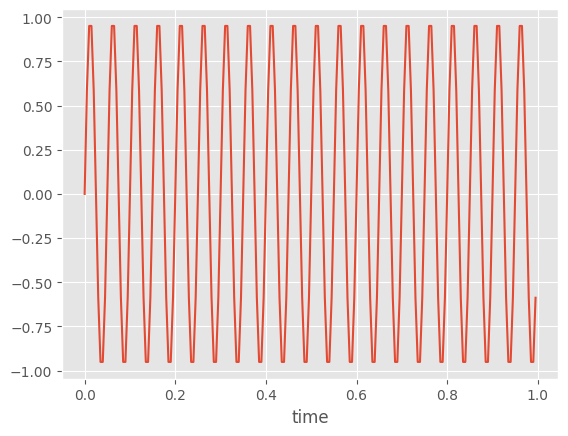

In [2]:
plt.plot(t,y)
plt.xlabel('time')
plt.show()

## Python (NumPy) vs. MATLAB vs. C – Syntax und Array-Verarbeitung

Viele Berechnungen in der Signalverarbeitung und Messtechnik arbeiten mit **Arrays** (Vektoren, Matrizen). Hier siehst du dieselbe Aufgabe in **Python/NumPy**, **MATLAB** und **C**. Die Gemeinsamkeiten zwischen Python und MATLAB liegen in der **vektorisierten** Array-Verarbeitung; in C muss typischerweise mit Schleifen gearbeitet werden.

### Gemeinsamkeiten: Array-Verarbeitung

- **Python (NumPy)** und **MATLAB** bieten eingebaute Array-Typen und **vektorisierte Operationen**: Du schreibst z. B. `y= np.sin(2 * np.pi * f * t)` und die Sinusfunktion wird auf **alle** Elemente von `t` angewendet, ohne explizite Schleife.
- Beide unterstützen **Indizierung**, **Slicing** und Operationen auf ganzen Arrays (Addition, Multiplikation elementweise).
- In **C** gibt es keine solchen Array-Operationen „auf einen Schlag“ – man legt ein Array an und durchläuft es in einer **for**-Schleife, um jeden Eintrag zu berechnen.

Das folgende Beispiel: Zeitvektor $t$ erzeugen, dann $y(t) = \sin(2\pi f t)$ berechnen (z. B. $f = 10\,\mathrm{Hz}$, 200 Punkte).

### Python (NumPy) – ausführbar im Notebook

In [3]:
import numpy as np

f = 10.0
N = 200
t = np.linspace(0, 1, N, endpoint=False)   # 200 Punkte, 0 bis 1 (ohne Endpunkt)
y = np.sin(2 * np.pi * f * t)               # vektorisiert: sin auf alle Elemente

print("Länge:", len(t), "  Summe x:", np.sum(y))
print("t[0:5] =", t[:5])

Länge: 200   Summe x: -1.0658141036401503e-14
t[0:5] = [0.    0.005 0.01  0.015 0.02 ]


### Äquivalenter MATLAB-Code

In MATLAB ist die Syntax sehr ähnlich; Funktionen wie `linspace` und `sin` arbeiten ebenfalls vektorisiert.

```matlab
f = 10.0;
N = 200;
t = (0:N-1) / N;          % wie NumPy linspace(0,1,N,endpoint=False)
y= sin(2*pi*f*t);        % vektorisiert: sin auf alle Elemente

disp(['Länge: ', num2str(length(t)), '  Summe x: ', num2str(sum(y))]);
disp(t(1:5));
```

### Äquivalenter C-Code

In C müssen Arrays explizit angelegt und in einer Schleife gefüllt werden. Keine vektorisierten Operationen – jeder Wert wird einzeln berechnet.

```c
#include <stdio.h>
#include <math.h>
#define N 200

int main(void) {
    double f = 10.0;
    double t[N], y[N];
    double sum_y = 0.0;

    for (int i = 0; i < N; i++) {
        t[i] = (double)i / N;           /* Zeitvektor von Hand */
        y[i] = sin(2.0 * M_PI * f * t[i]);
        sum_y += y[i];
    }

    printf("Länge: %d  Summe y: %f\n", N, sum_y);
    for (int i = 0; i < 5; i++) printf("%f ", t[i]);
    return 0;
}
```

### Vorteile der NumPy-Arrays (und der MATLAB-Arrays)

| Aspekt | C | Python/NumPy, MATLAB |
|--------|---|----------------------|
| **Schreibweise** | Schleifen für jedes Element, Fehleranfälligkeit bei Indizes | Eine Zeile: `x = np.sin(2*np.pi*f*t)` |
| **Lesbarkeit** | Viel Boilerplate (Array, Schleife, Index) | Formel steht direkt da, nahe an der Mathematik |
| **Performance** | Manuell optimiert, aber aufwändig | NumPy nutzt C/Fortran-Routinen – schnell, ohne dass du Schleifen schreibst |
| **Flexibilität** | Feste Größe oder dynamische Verwaltung selbst programmieren | Größe dynamisch, viele fertige Funktionen (Summe, Mittelwert, FFT, …) |

**Kurz:** NumPy (und MATLAB) bringen die **Lesbarkeit** und **Kürze** vektorisierten Arbeitens mit Arrays; die rechenintensiven Teile laufen trotzdem effizient (C-Ebene). In C erreichst du vergleichbare Geschwindigkeit nur durch explizite Schleifen und manuelle Optimierung.

## AUFGABE:

Ändere den Python Code so, dass der Spitzenwert der Snusfunktion 0.6 wird und deren Frequenz 7 Hz beträgt!

In [1]:
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')

f = 4.0
t = np.linspace(0,1,200,endpoint=False)
y = 0.6*np.sin(2*np.pi*f*t)
#print(t,type(t))
#print(x,x.shape)

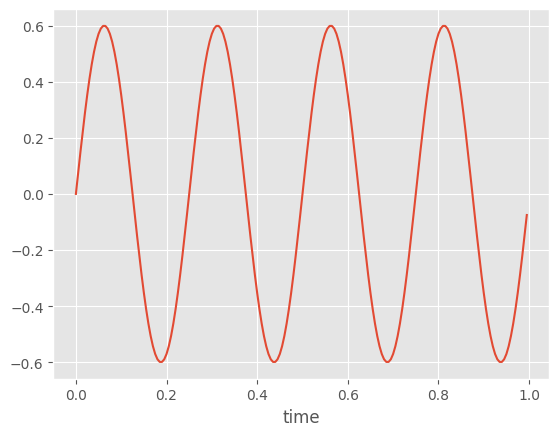

In [2]:
plt.plot(t,y)
plt.xlabel('time')
plt.show()

Erkläre, welche Parameter wie geändert wurden!

*Hier Antworttext einfügen:*  
es wurde f=7.0 gesetzt und die sinusfunktion mit 0.6 multipliziert.

Nächstes Notebook: [Sinus,Cosinus](02_sin_cos.ipynb)